# Parte 1

## Configuración de directorios

In [17]:
import os

# Directorios organizados
BASE_DIR = "PPM_Images"
UNENCRYPTED_DIR = os.path.join(BASE_DIR, "original")
ENCRYPTED_DIR = os.path.join(BASE_DIR, "encrypted")
DECRYPTED_DIR = os.path.join(BASE_DIR, "decrypted")

# Crear los directorios si no existen
os.makedirs(UNENCRYPTED_DIR, exist_ok=True)
os.makedirs(ENCRYPTED_DIR, exist_ok=True)
os.makedirs(DECRYPTED_DIR, exist_ok=True)

print("Directorios creados/verificados correctamente.")

Directorios creados/verificados correctamente.


## Cargar y Mostrar la Imagen Original

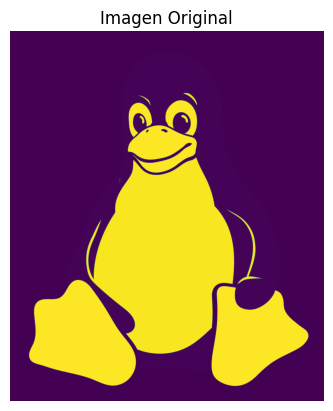

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Cargar la imagen en escala de grises
image_path = os.path.join(UNENCRYPTED_DIR, "tux.ppm")
img = Image.open(image_path).convert("L")

# Mostrar la imagen original
plt.imshow(img)
plt.title("Imagen Original")
plt.axis("off")
plt.show()

## Convertir la Imagen a Bytes

In [19]:
import io

# Convertir imagen a bytes
def image_to_bytes(image_path):
    with open(image_path, "rb") as img_file:
        return img_file.read()

# Guardar la imagen en bytes
img_bytes = np.array(img).tobytes()

print(f"Imagen convertida a {len(img_bytes)} bytes.")

Imagen convertida a 1026300 bytes.


## Generación de Clave AES y IV

In [20]:
import secrets
from Crypto.Cipher import AES

def generate_aes_key():
    """Genera una clave aleatoria de 256 bits (32 bytes) para AES."""
    return secrets.token_bytes(32)  # AES-256 usa una clave de 32 bytes

def generate_iv():
    """Genera un IV aleatorio de 16 bytes (128 bits) para AES-CBC."""
    return secrets.token_bytes(16)

# Generamos clave y IV
key = generate_aes_key()
iv = generate_iv()

print(f"Clave AES generada (hex): {key.hex()}")
print(f"IV AES generado (hex): {iv.hex()}")

Clave AES generada (hex): 032329efbc826d0dbee8ff97bfb72e97efec46673228ed541e37b9bd1d39a9b1
IV AES generado (hex): 873fa2dcb47f1fc6500363b17307a911


## Cifrado AES en ECB

In [21]:
from Crypto.Util.Padding import pad, unpad

def encrypt_aes_ecb(data, key):
    """Cifra los datos usando AES en modo ECB."""
    cipher = AES.new(key, AES.MODE_ECB)
    encrypted_data = cipher.encrypt(pad(data, AES.block_size))  # Aplica padding automático
    return encrypted_data

# Cifrar la imagen en ECB
encrypted_ecb = encrypt_aes_ecb(img_bytes, key)

print(f"Imagen cifrada con ECB (tamaño): {len(encrypted_ecb)} bytes.")

Imagen cifrada con ECB (tamaño): 1026304 bytes.


## Cifrado AES en CBC

In [22]:
def encrypt_aes_cbc(data, key, iv):
    """Cifra los datos usando AES en modo CBC."""
    cipher = AES.new(key, AES.MODE_CBC, iv)
    encrypted_data = cipher.encrypt(pad(data, AES.block_size))
    return encrypted_data

# Cifrar la imagen en CBC
encrypted_cbc = encrypt_aes_cbc(img_bytes, key, iv)

print(f"Imagen cifrada con CBC (tamaño): {len(encrypted_cbc)} bytes.")

Imagen cifrada con CBC (tamaño): 1026304 bytes.


## Función para Guardar Datos Cifrados

In [23]:
def save_encrypted_image(encrypted_data, filename):
    """Guarda los datos cifrados en la carpeta ENCRYPTED."""
    path = os.path.join(ENCRYPTED_DIR, filename)
    with open(path, "wb") as file:
        file.write(encrypted_data)
    print(f"Imagen cifrada guardada en: {path}")

# Guardar imágenes cifradas
save_encrypted_image(encrypted_ecb, "encrypted_ecb.ppm")
save_encrypted_image(encrypted_cbc, "encrypted_cbc.ppm")

Imagen cifrada guardada en: PPM_Images/encrypted/encrypted_ecb.ppm
Imagen cifrada guardada en: PPM_Images/encrypted/encrypted_cbc.ppm


## Ver imagenes cifradas

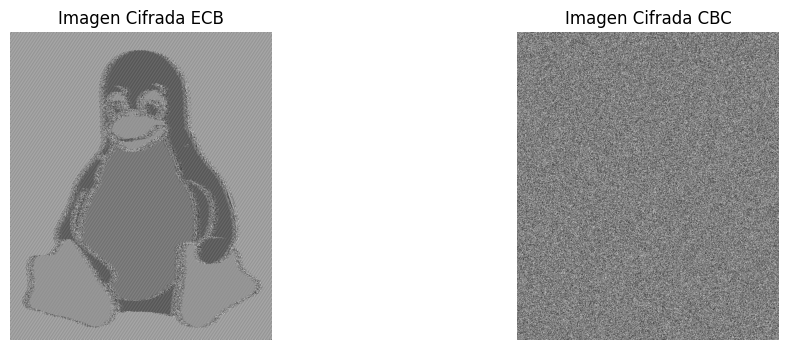

In [30]:
# In[24] - Visualizar las imágenes cifradas en ECB y CBC

# Cargar los datos cifrados desde los archivos
encrypted_ecb_path = os.path.join(ENCRYPTED_DIR, "encrypted_ecb.ppm")
encrypted_cbc_path = os.path.join(ENCRYPTED_DIR, "encrypted_cbc.ppm")

with open(encrypted_ecb_path, "rb") as file:
    encrypted_ecb_data = file.read()

with open(encrypted_cbc_path, "rb") as file:
    encrypted_cbc_data = file.read()

# Convertir los datos cifrados a una matriz para visualización
encrypted_ecb_array = np.frombuffer(encrypted_ecb_data, dtype=np.uint8)
encrypted_cbc_array = np.frombuffer(encrypted_cbc_data, dtype=np.uint8)

# Redimensionar para que tenga una forma cuadrada o rectangular razonable
image_size = img.height * img.width  # Cantidad de píxeles
encrypted_ecb_array = encrypted_ecb_array[:image_size].reshape((img.height, img.width))
encrypted_cbc_array = encrypted_cbc_array[:image_size].reshape((img.height, img.width))

# Mostrar las imágenes cifradas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(encrypted_ecb_array, cmap="gray")
axes[0].set_title("Imagen Cifrada ECB")
axes[0].axis("off")

axes[1].imshow(encrypted_cbc_array, cmap="gray")
axes[1].set_title("Imagen Cifrada CBC")
axes[1].axis("off")

plt.show()

## Función para Guardar Imágenes Descifradas

In [24]:
def save_decrypted_image(decrypted_data, filename):
    """Guarda la imagen descifrada en la carpeta DECRYPTED."""
    try:
        # Reconstruir la imagen en escala de grises usando numpy array
        arr = np.frombuffer(decrypted_data, dtype=np.uint8)
        arr = arr.reshape((img.height, img.width))
        img_dec = Image.fromarray(arr, mode="L")
        path = os.path.join(DECRYPTED_DIR, filename)
        img_dec.save(path, format="PPM")
        print(f"Imagen descifrada guardada en: {path}")
    except Exception as e:
        print(f"Error al guardar la imagen descifrada: {e}")

## Descifrado AES en ECB

In [25]:
def decrypt_aes_ecb(encrypted_data, key):
    """Descifra los datos usando AES en modo ECB."""
    cipher = AES.new(key, AES.MODE_ECB)
    decrypted_data = unpad(cipher.decrypt(encrypted_data), AES.block_size)
    return decrypted_data

# Descifrar la imagen en ECB
decrypted_ecb = decrypt_aes_ecb(encrypted_ecb, key)

# Guardar la imagen descifrada
save_decrypted_image(decrypted_ecb, "decrypted_ecb.png")

print("Imagen descifrada correctamente en ECB.")

Imagen descifrada guardada en: PPM_Images/decrypted/decrypted_ecb.png
Imagen descifrada correctamente en ECB.


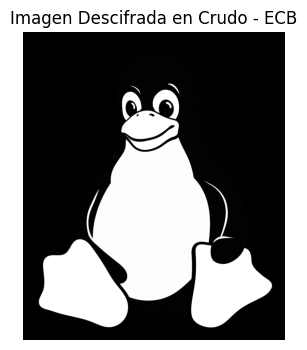

In [26]:
# Mostrar la imagen descifrada en crudo (RAW BYTES) para ECB
raw_ecb_array = np.frombuffer(decrypted_ecb, dtype=np.uint8)
raw_ecb_array = raw_ecb_array.reshape((img.height, img.width))

plt.figure(figsize=(8, 4))
plt.imshow(raw_ecb_array, cmap="gray")
plt.title("Imagen Descifrada en Crudo - ECB")
plt.axis("off")
plt.show()

## Descifrado AES en CBC

In [27]:
def decrypt_aes_cbc(encrypted_data, key, iv):
    """Descifra los datos usando AES en modo CBC."""
    cipher = AES.new(key, AES.MODE_CBC, iv)
    decrypted_data = unpad(cipher.decrypt(encrypted_data), AES.block_size)
    return decrypted_data

# Descifrar la imagen en CBC
decrypted_cbc = decrypt_aes_cbc(encrypted_cbc, key, iv)

# Guardar la imagen descifrada
save_decrypted_image(decrypted_cbc, "decrypted_cbc.png")

print("Imagen descifrada correctamente en CBC.")

Imagen descifrada guardada en: PPM_Images/decrypted/decrypted_cbc.png
Imagen descifrada correctamente en CBC.


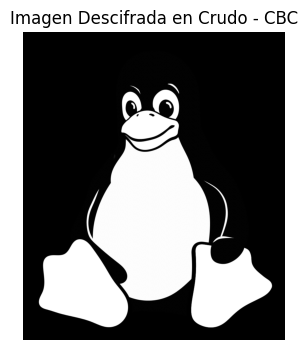

In [28]:
# Mostrar la imagen descifrada en crudo (RAW BYTES) para CBC
raw_cbc_array = np.frombuffer(decrypted_cbc, dtype=np.uint8)
raw_cbc_array = raw_cbc_array.reshape((img.height, img.width))

plt.figure(figsize=(8, 4))
plt.imshow(raw_cbc_array, cmap="gray")
plt.title("Imagen Descifrada en Crudo - CBC")
plt.axis("off")
plt.show()

## Mostrar las Imágenes Descifradas

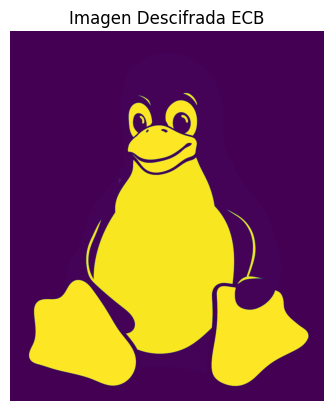

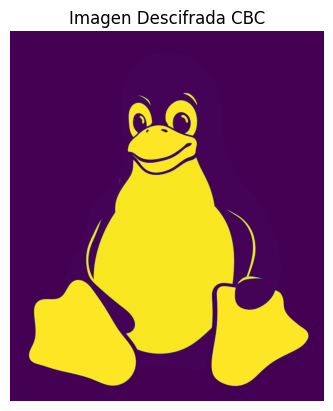

In [29]:
# Cargar y mostrar la imagen descifrada en ECB
img_dec_ecb = Image.open(os.path.join(DECRYPTED_DIR, "decrypted_ecb.png"))
plt.imshow(img_dec_ecb)
plt.title("Imagen Descifrada ECB")
plt.axis("off")
plt.show()

# Cargar y mostrar la imagen descifrada en CBC
img_dec_cbc = Image.open(os.path.join(DECRYPTED_DIR, "decrypted_cbc.png"))
plt.imshow(img_dec_cbc)
plt.title("Imagen Descifrada CBC")
plt.axis("off")
plt.show()

## Preguntas para reflexión Parte 1

* ¿Por qué el cifrado ECB revela los patrones de la imagen?
    * porque cada bloque de texto plano se cifra de forma independiente utilizando la misma clave. Esto significa que bloques idénticos en el texto plano producirán bloques idénticos en el texto cifrado. Al aplicar ECB a una imagen, los patrones repetitivos en los datos originales se mantienen en el texto cifrado, lo que permite que los patrones de la imagen original sean visibles incluso después del cifrado. Por ejemplo, si una imagen contiene áreas de color uniforme o patrones repetitivos, estos serán evidentes en la versión cifrada con ECB
* ¿Cómo cambia la apariencia con CBC?
    * hay mucho ruido en toda la imagen, no se logra ver nada, son solo pixeles de diferentes colores esto pasa porque antes de cifrar cada bloque de texto plano, se realiza una operación XOR con el bloque cifrado anterior, y el primer bloque utiliza un vector de inicialización (IV) para garantizar la aleatoriedad. Esta interdependencia asegura que incluso si hay bloques de texto plano idénticos, los bloques cifrados resultantes serán diferentes, eliminando patrones visibles en la imagen cifrada.
* ¿Qué tan seguro es usar ECB para cifrar datos estructurados?
    * es muy inseguro, porque ECB no oculta patrones en el texto plano, bloques idénticos en el texto plano resultan en bloques idénticos en el texto cifrado.Esto permite a un atacante identificar patrones y potencialmente inferir información sensible del texto cifrado. ECB no es recomendado para datos que contienen estructuras o patrones repetitivos.

## Referencias 
* https://es.eitca.org/la-seguridad-cibernética/eitc-es-ccf-fundamentos-de-la-criptografía-clásica/aplicaciones-de-cifrados-en-bloque/modos-de-operación-para-cifrados-en-bloque/modos-de-operación-de-revisión-de-examen-para-cifrados-de-bloque/¿Cómo-funciona-el-modo-de-funcionamiento-del-BCE-con-libro-de-códigos-electrónico-y-cuáles-son-sus-principales-inconvenientes-de-seguridad%3F/
* https://www.certsuperior.com/criptografia-simetrica/


# Parte 2

Ver el documento [pdf](Parte2Lab3-2.pdf)

# Parte 3

## Cifrado y descifrado con ChaCha20

In [34]:
from Crypto.Cipher import ChaCha20
from Crypto.Random import get_random_bytes
import timeit
import memory_profiler

def chacha20_encrypt(plaintext):
    """Cifra un mensaje usando ChaCha20."""
    key = get_random_bytes(32)  # ChaCha20 usa una clave de 256 bits (32 bytes)
    nonce = get_random_bytes(12)  # ChaCha20 usa un nonce de 96 bits (12 bytes)

    cipher = ChaCha20.new(key=key, nonce=nonce)
    ciphertext = cipher.encrypt(plaintext.encode())

    return key, nonce, ciphertext

def chacha20_decrypt(key, nonce, ciphertext):
    """Descifra un mensaje cifrado con ChaCha20."""
    cipher = ChaCha20.new(key=key, nonce=nonce)
    plaintext = cipher.decrypt(ciphertext)
    return plaintext.decode()

# Mensaje de prueba
mensaje_prueba = "Mensaje de prueba con ChaCha20"

# Cifrado
key, nonce, mensaje_cifrado = chacha20_encrypt(mensaje_prueba)
print(f"Mensaje cifrado (hex): {mensaje_cifrado.hex()}")

# Descifrado
mensaje_descifrado = chacha20_decrypt(key, nonce, mensaje_cifrado)
print(f"Mensaje descifrado: {mensaje_descifrado}")

Mensaje cifrado (hex): 8b89e5f32c9e9f31d4df4e733780d2234942373cdcaa05fad111e6ebf60f
Mensaje descifrado: Mensaje de prueba con ChaCha20


##  Cifrado y Descifrado con AES-CBC

In [35]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad

def aes_encrypt(plaintext):
    """Cifra un mensaje usando AES en modo CBC."""
    key = get_random_bytes(16)  # Clave de 128 bits
    iv = get_random_bytes(16)  # IV de 128 bits

    cipher = AES.new(key, AES.MODE_CBC, iv)
    ciphertext = cipher.encrypt(pad(plaintext.encode(), AES.block_size))

    return key, iv, ciphertext

def aes_decrypt(key, iv, ciphertext):
    """Descifra un mensaje cifrado con AES-CBC."""
    cipher = AES.new(key, AES.MODE_CBC, iv)
    plaintext = cipher.decrypt(ciphertext)
    return plaintext.decode()

# Mensaje de prueba
mensaje_prueba = "Mensaje de prueba con AES"

# Cifrado
key, iv, mensaje_cifrado = aes_encrypt(mensaje_prueba)
print(f"Mensaje cifrado (hex): {mensaje_cifrado.hex()}")

# Descifrado
mensaje_descifrado = aes_decrypt(key, iv, mensaje_cifrado)
print(f"Mensaje descifrado: {mensaje_descifrado}")

Mensaje cifrado (hex): 94f62df56ca19f93d6dec892a3e4a8b4eb8edfa5160ea5bc14f787c4548e3b6b
Mensaje descifrado: Mensaje de prueba con AES


## Comparación de Tiempo de Ejecución

In [36]:
# Pruebas de tiempo
chacha20_time = timeit.timeit(lambda: chacha20_encrypt(mensaje_prueba), number=1000)
aes_time = timeit.timeit(lambda: aes_encrypt(mensaje_prueba), number=1000)

print(f"Tiempo de ChaCha20: {chacha20_time:.6f} segundos")
print(f"Tiempo de AES-CBC: {aes_time:.6f} segundos")

Tiempo de ChaCha20: 0.007799 segundos
Tiempo de AES-CBC: 0.009256 segundos


## Medición de Consumo de Memoria por Algoritmo

In [37]:
def medir_memoria_chacha():
    chacha20_encrypt(mensaje_prueba)

def medir_memoria_aes():
    aes_encrypt(mensaje_prueba)

# Medición individual para ChaCha20
memoria_chacha = memory_profiler.memory_usage(medir_memoria_chacha)
print(f"Consumo de memoria de ChaCha20: {max(memoria_chacha)} MB")

# Medición individual para AES-CBC
memoria_aes = memory_profiler.memory_usage(medir_memoria_aes)
print(f"Consumo de memoria de AES-CBC: {max(memoria_aes)} MB")

Consumo de memoria de ChaCha20: 33.421875 MB
Consumo de memoria de AES-CBC: 33.90625 MB


## Preguntas para reflexionar Parte 3
* ¿Analizar que cifrado es mas rápido ChaCha20 o AES?
    * ChaCha20 suele ser más rápido debido a su diseño optimizado para software. Esto se debe a que ChaCha20 realiza operaciones más simples y eficientes en software, lo que reduce el tiempo de procesamiento en comparación con AES
    * la mayor velocidad de ChaCha20 en entornos sin aceleración de hardware se atribuye a su diseño como cifrador de flujo, que realiza operaciones más eficientes en software en comparación con el cifrado por bloques de AES
* ¿En qué casos debería usarse en vez de AES?
    * ChaCha20 es especialmente adecuado en dispositivos móviles y sistemas embebidos donde la aceleración de hardware para AES no está disponible, ofreciendo un rendimiento más eficiente

## Referencias 

* https://nordpass.com/blog/xchacha20-encryption-vs-aes-256/
* https://medium.com/%40parejaemi/algoritmo-de-cifrado-chacha20-119a6d7c19a7
* https://www.redeszone.net/tutoriales/seguridad/criptografia-algoritmos-clave-simetrica-asimetrica/


# Parte 4

## Preparación del entorno

In [38]:
import os

# Crear directorio de prueba
os.makedirs("carpeta_prueba", exist_ok=True)

# Crear archivos de texto de ejemplo
for i in range(1, 4):
    with open(f"carpeta_prueba/archivo_{i}.txt", "w") as f:
        f.write(f"Este es el contenido del archivo {i}.")

## Implementar el script de cifrado con AES

In [46]:
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes
from cryptography.hazmat.primitives import padding
from cryptography.hazmat.backends import default_backend
import os

def generar_clave():
    return os.urandom(32)  # Clave de 256 bits

def generar_iv():
    return os.urandom(16)  # IV de 128 bits

def cifrar_archivo(ruta_archivo, clave, iv):
    with open(ruta_archivo, "rb") as archivo:
        datos = archivo.read()

    # Añadir padding
    padder = padding.PKCS7(algorithms.AES.block_size).padder()
    datos_padded = padder.update(datos) + padder.finalize()

    # Cifrar datos
    cipher = Cipher(algorithms.AES(clave), modes.CBC(iv), backend=default_backend())
    encryptor = cipher.encryptor()
    datos_cifrados = encryptor.update(datos_padded) + encryptor.finalize()

    # Guardar datos cifrados
    with open(ruta_archivo, "wb") as archivo:
        archivo.write(iv + datos_cifrados)  # Guardamos el IV al inicio del archivo

# Generar clave y guardarla en un archivo
clave = generar_clave()
with open("clave.key", "wb") as clave_archivo:
    clave_archivo.write(clave)

# Cifrar todos los archivos de texto en la carpeta de prueba
carpeta_prueba = "carpeta_prueba"
for nombre_archivo in os.listdir(carpeta_prueba):
    ruta_archivo = os.path.join(carpeta_prueba, nombre_archivo)
    if os.path.isfile(ruta_archivo) and ruta_archivo.endswith(".txt"):
        iv = generar_iv()
        cifrar_archivo(ruta_archivo, clave, iv)
        print(f"{ruta_archivo} ha sido cifrado.")

carpeta_prueba/archivo_1.txt ha sido cifrado.
carpeta_prueba/archivo_2.txt ha sido cifrado.
carpeta_prueba/archivo_3.txt ha sido cifrado.


## Aplicar el descifrado

In [41]:
import shutil

# Definir la carpeta de copia
carpeta_copia = "carpeta_cifrada_copia"
shutil.copytree(carpeta_prueba, carpeta_copia)
print(f"Se ha creado una copia de la carpeta cifrada en: {carpeta_copia}")

Se ha creado una copia de la carpeta cifrada en: carpeta_cifrada_copia


In [43]:
# Función para descifrar un archivo
def descifrar_archivo(ruta_archivo, clave):
    with open(ruta_archivo, "rb") as archivo:
        datos = archivo.read()

    # Extraer IV y datos cifrados
    iv = datos[:16]
    datos_cifrados = datos[16:]

    # Descifrar datos
    cipher = Cipher(algorithms.AES(clave), modes.CBC(iv), backend=default_backend())
    decryptor = cipher.decryptor()
    datos_padded = decryptor.update(datos_cifrados) + decryptor.finalize()

    # Remover padding
    unpadder = padding.PKCS7(algorithms.AES.block_size).unpadder()
    datos = unpadder.update(datos_padded) + unpadder.finalize()

    # Guardar datos descifrados
    with open(ruta_archivo, "wb") as archivo:
        archivo.write(datos)

In [45]:
# Cargar la clave desde el archivo
with open("clave.key", "rb") as clave_archivo:
    clave = clave_archivo.read()

# Descifrar todos los archivos de texto en la carpeta de prueba
for nombre_archivo in os.listdir(carpeta_copia):
    ruta_archivo = os.path.join(carpeta_copia, nombre_archivo)
    if os.path.isfile(ruta_archivo) and ruta_archivo.endswith(".txt"):
        descifrar_archivo(ruta_archivo, clave)
        print(f"{ruta_archivo} ha sido descifrado.")

carpeta_cifrada_copia/archivo_1.txt ha sido descifrado.
carpeta_cifrada_copia/archivo_2.txt ha sido descifrado.
carpeta_cifrada_copia/archivo_3.txt ha sido descifrado.


## Preguntas para reflexión Parte 4

* ¿Cómo podríamos evitar ataques de ransomware?
    * Instalando las últimas actualizaciones de SO para corregir vulenrabilidades o reducir el riesgo de usar vulnerabilidades existentes por lo que hay que encontras nuevas que es más díficil 
    * implmentar antivirus 
* ¿Qué tan importante es almacenar claves de manera segura?
    *  Si una clave se pierde o es robada, los datos cifrados pueden quedar inaccesibles o ser comprometidos. Se recomienda utilizar módulos de seguridad de hardware (TPM) o gestores de contraseñas confiables para almacenar y gestionar estas claves de forma segura 

## Referencias 

* https://www.fortinet.com/lat/resources/cyberglossary/how-to-prevent-ransomware
* https://utimaco.com/es/noticias/entradas-de-blog/comprender-la-importancia-del-cifrado
* https://www.trendmicro.com/es_es/what-is/ransomware/how-to-prevent.html